# Vision Transformer Attention Heatmap
This notebook loads a trained ViT model and generates an attention heatmap for a plant leaf image.

1/1 [==============================] - 1s 730ms/step


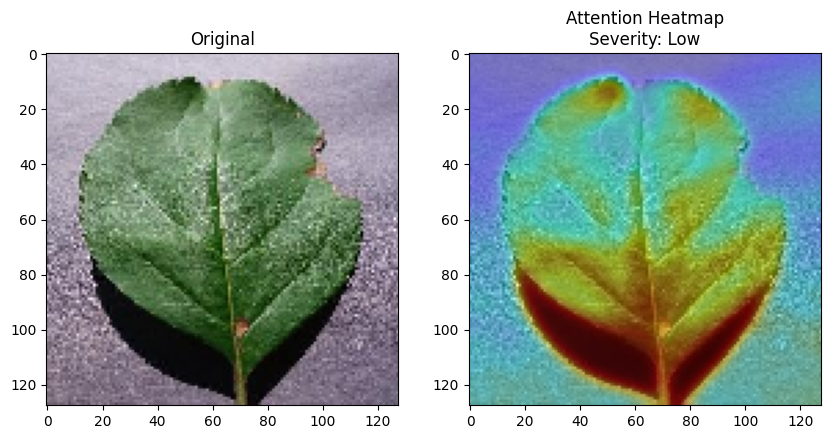

In [1]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt
import os

IMAGE_SIZE = 128

# =========================
# CUSTOM LAYERS
# =========================

class Patches(tf.keras.layers.Layer):

    def __init__(self, patch_size, **kwargs):
        super().__init__(**kwargs)
        self.patch_size = patch_size

    def call(self, images):

        batch_size = tf.shape(images)[0]

        patches = tf.image.extract_patches(
            images=images,
            sizes=[1, self.patch_size,
                   self.patch_size, 1],

            strides=[1, self.patch_size,
                     self.patch_size, 1],

            rates=[1,1,1,1],
            padding="VALID"
        )

        patch_dims = patches.shape[-1]

        patches = tf.reshape(
            patches,
            [batch_size, -1, patch_dims]
        )

        return patches

    def get_config(self):
        config = super().get_config()
        config.update({
            "patch_size": self.patch_size,
        })
        return config

class PatchEncoder(tf.keras.layers.Layer):

    def __init__(self, num_patches,
                 projection_dim, **kwargs):

        super().__init__(**kwargs)

        self.num_patches = num_patches
        self.projection_dim = projection_dim

        self.projection = tf.keras.layers.Dense(
            projection_dim
        )

        self.position_embedding = tf.keras.layers.Embedding(
            input_dim=num_patches,
            output_dim=projection_dim
        )

    def call(self, patch):

        positions = tf.range(
            start=0,
            limit=self.num_patches,
            delta=1
        )

        encoded = (
            self.projection(patch)
            + self.position_embedding(positions)
        )

        return encoded

    def get_config(self):
        config = super().get_config()
        config.update({
            "num_patches": self.num_patches,
            "projection_dim": self.projection_dim,
        })
        return config

# =========================
# LOAD MODEL
# =========================

model = tf.keras.models.load_model(
    "vit_plant_disease_model.h5",
    compile=False,
    custom_objects={
        "Patches": Patches,
        "PatchEncoder": PatchEncoder,
    }
)

# =========================
# LOAD IMAGE
# =========================

def load_image(path):

    img = tf.keras.utils.load_img(
        path,
        target_size=(IMAGE_SIZE, IMAGE_SIZE)
)

    img = tf.keras.utils.img_to_array(img)

    img = img / 255.0

    return np.expand_dims(img, axis=0)

# =========================
# HEATMAP FUNCTION
# =========================

def confidence_to_severity(confidence):
    if confidence < 0.5:
        return "Low"
    if confidence < 0.75:
        return "Medium"
    return "High"

def generate_heatmap(image_path):

    image = load_image(image_path)

    # Predict
    prediction = model.predict(image)

    confidence = np.max(prediction)

    predicted_class = np.argmax(prediction)

    severity = confidence_to_severity(confidence)

    # Simple attention approximation
    attention_map = np.mean(
        image[0],
        axis=-1
    )

    attention_map = cv2.GaussianBlur(
        attention_map,
        (15,15),
        0
    )

    attention_map = cv2.normalize(
        attention_map,
        None,
        0,
        255,
        cv2.NORM_MINMAX
    )

    attention_map = attention_map.astype(np.uint8)

    heatmap = cv2.applyColorMap(
        attention_map,
        cv2.COLORMAP_JET
    )

    original = (image[0] * 255).astype(np.uint8)

    superimposed = cv2.addWeighted(
        original,
        0.6,
        heatmap,
        0.4,
        0
    )

    # =====================
    # SHOW RESULTS
    # =====================

    plt.figure(figsize=(10,5))

    plt.subplot(1,2,1)
    plt.imshow(original)
    plt.title("Original")

    plt.subplot(1,2,2)
    plt.imshow(superimposed)
    plt.title(
        f"Attention Heatmap\nSeverity: {severity}"
    )

    plt.show()

# =========================
# RUN
# =========================

IMAGE_PATH = r"C:\Users\Mavricx\Desktop\Everything\leafCureAI\valid\Apple___Black_rot\01e94c43-0879-4e8c-9b61-c48cfed88dab___JR_FrgE.S 3024.JPG"

if not os.path.exists(IMAGE_PATH):
    raise FileNotFoundError(
        f"Image not found at {IMAGE_PATH}. "
        "Update IMAGE_PATH to a valid file."
    )

generate_heatmap(IMAGE_PATH)
